In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("mahasiswa_lulus.csv")

In [ ]:
df.head()

,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Lulus_Tepat_Waktu
0,3.79,65,12,Ya,5200000,Perempuan,Ya,Ya
1,3.80,80,5,Tidak,6100000,Perempuan,Ya,Ya
2,4.00,82,16,Tidak,2550000,Laki-laki,Tidak,Ya
3,2.71,83,14,Tidak,2400000,Perempuan,Tidak,Tidak
4,2.97,87,14,Tidak,2550000,Perempuan,Tidak,Ya


In [ ]:

print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])

print("\nNama kolom:")
print(df.columns.tolist())

print("\nJumlah missing value:")
print(df.isnull().sum())

Jumlah data: 500
Jumlah fitur: 8

Nama kolom:
['IPK', 'Kehadiran', 'Jam_Belajar', 'Organisasi', 'Penghasilan_Ortu', 'Jenis_Kelamin', 'Status_Beasiswa', 'Lulus_Tepat_Waktu']

Jumlah missing value:
IPK                  0
Kehadiran            0
Jam_Belajar          0
Organisasi           0
Penghasilan_Ortu     0
Jenis_Kelamin        0
Status_Beasiswa      0
Lulus_Tepat_Waktu    0
dtype: int64


In [ ]:
X = df.drop("Lulus_Tepat_Waktu", axis=1)
y = df["Lulus_Tepat_Waktu"]

print("Jumlah data fitur:", X.shape)
print("Jumlah data target:", y.shape)

Jumlah data fitur: (500, 7)
Jumlah data target: (500,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

le = LabelEncoder()

X_encoded["Organisasi"] = le.fit_transform(X_encoded["Organisasi"])
X_encoded["Jenis_Kelamin"] = le.fit_transform(X_encoded["Jenis_Kelamin"])
X_encoded["Status_Beasiswa"] = le.fit_transform(X_encoded["Status_Beasiswa"])

y_encoded = le.fit_transform(y)

print(X_encoded.head())

    IPK  Kehadiran  Jam_Belajar  Organisasi  Penghasilan_Ortu  Jenis_Kelamin  \
0  3.79         65           12           1           5200000              1   
1  3.80         80            5           0           6100000              1   
2  4.00         82           16           0           2550000              0   
3  2.71         83           14           0           2400000              1   
4  2.97         87           14           0           2550000              1   

   Status_Beasiswa  
0                1  
1                1  
2                0  
3                0  
4                0  


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Data training:", X_train.shape[0])
print("Data testing :", X_test.shape[0])

Data training: 400
Data testing : 100


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_depth3.fit(X_train, y_train)

y_pred_dt3 = dt_depth3.predict(X_test)

print("Decision Tree max_depth=3 berhasil dibuat.")

Decision Tree max_depth=3 berhasil dibuat.


In [ ]:
dt_unlimited = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

dt_unlimited.fit(X_train, y_train)

y_pred_dt_unlimited = dt_unlimited.predict(X_test)

print("Decision Tree max_depth=None berhasil dibuat.")

Decision Tree max_depth=None berhasil dibuat.


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Gaussian Naive Bayes berhasil dibuat.")

Gaussian Naive Bayes berhasil dibuat.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluasi_model(nama_model, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{nama_model}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

evaluasi_model(
    "Decision Tree max_depth=3",
    y_test,
    y_pred_dt3
)

evaluasi_model(
    "Decision Tree max_depth=None",
    y_test,
    y_pred_dt_unlimited
)

evaluasi_model(
    "Gaussian Naive Bayes",
    y_test,
    y_pred_nb
)


Decision Tree max_depth=3
Accuracy  : 0.8000
Precision : 0.7821
Recall    : 0.9531
F1-Score  : 0.8592

Decision Tree max_depth=None
Accuracy  : 0.7500
Precision : 0.7826
Recall    : 0.8438
F1-Score  : 0.8120

Gaussian Naive Bayes
Accuracy  : 0.6400
Precision : 0.6400
Recall    : 1.0000
F1-Score  : 0.7805


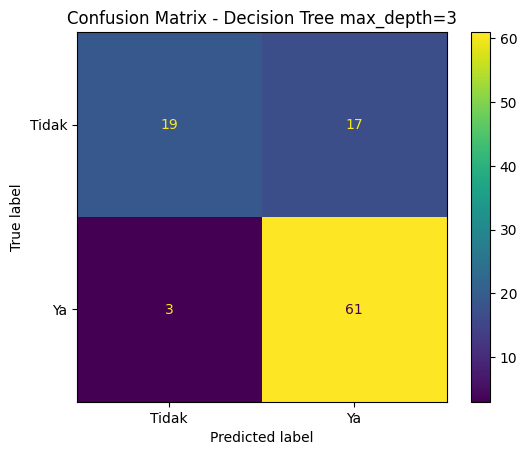

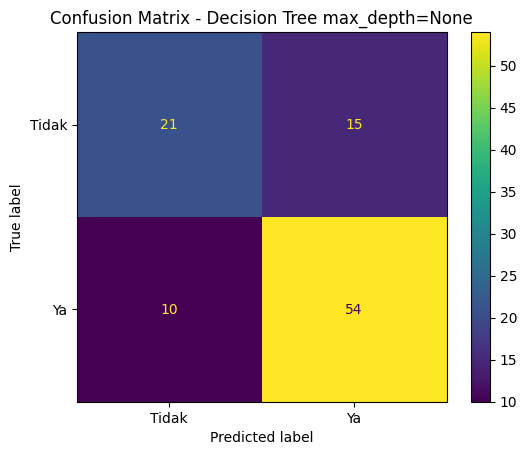

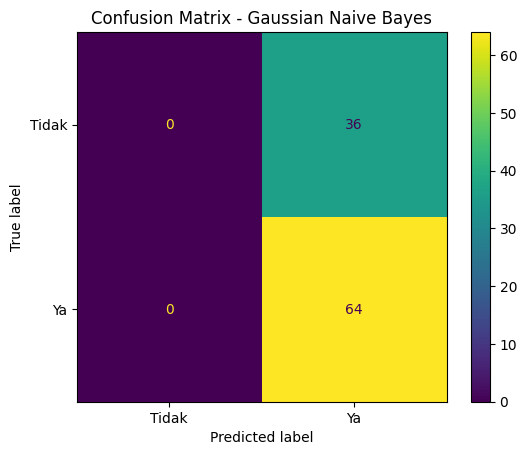

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt3 = confusion_matrix(y_test, y_pred_dt3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt3,
    display_labels=["Tidak", "Ya"]
)
disp.plot()
plt.title("Confusion Matrix - Decision Tree max_depth=3")
plt.show()


cm_dt_unlimited = confusion_matrix(y_test, y_pred_dt_unlimited)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_unlimited,
    display_labels=["Tidak", "Ya"]
)
disp.plot()
plt.title("Confusion Matrix - Decision Tree max_depth=None")
plt.show()


cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Tidak", "Ya"]
)
disp.plot()
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()

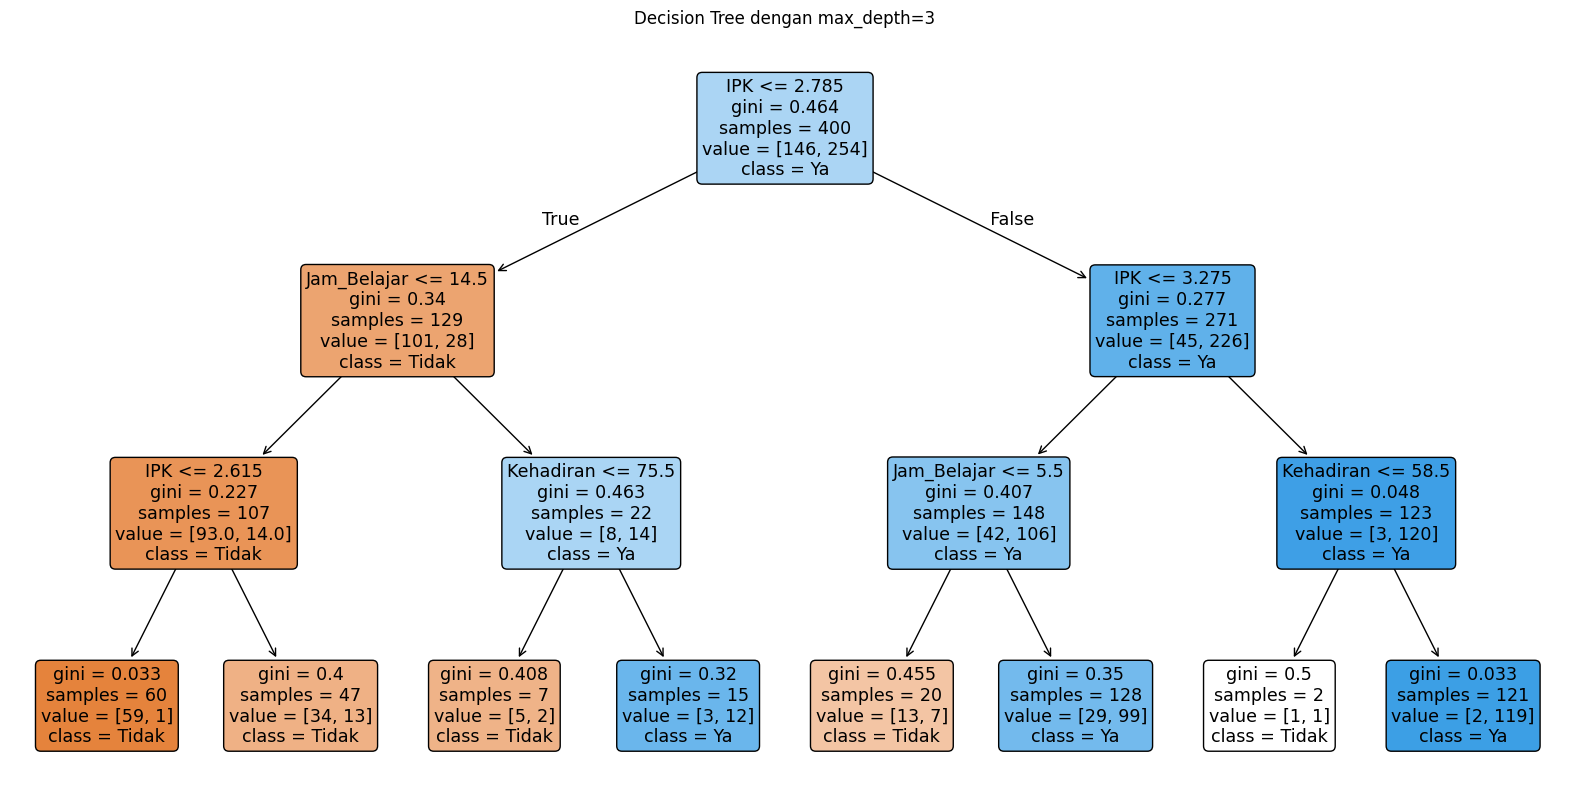

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_depth3,
    feature_names=X_encoded.columns,
    class_names=["Tidak", "Ya"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree dengan max_depth=3")
plt.show()

In [ ]:
hasil = pd.DataFrame({
    "Model": [
        "Decision Tree max_depth=3",
        "Decision Tree max_depth=None",
        "Gaussian Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt3),
        accuracy_score(y_test, y_pred_dt_unlimited),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt3),
        precision_score(y_test, y_pred_dt_unlimited),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt3),
        recall_score(y_test, y_pred_dt_unlimited),
        recall_score(y_test, y_pred_nb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt3),
        f1_score(y_test, y_pred_dt_unlimited),
        f1_score(y_test, y_pred_nb)
    ]
})

hasil.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree max_depth=3,0.80,0.7821,0.9531,0.8592
1,Decision Tree max_depth=None,0.75,0.7826,0.8438,0.8120
2,Gaussian Naive Bayes,0.64,0.6400,1.0000,0.7805


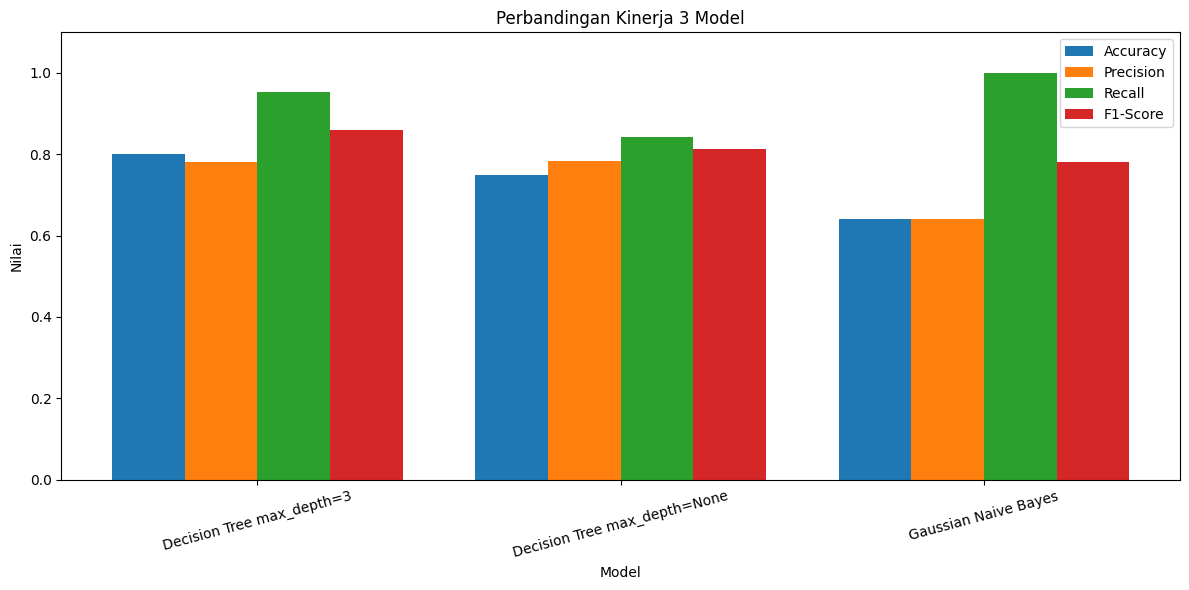

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = hasil["Model"]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, hasil["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, hasil["Precision"], width, label="Precision")
plt.bar(x + 0.5*width, hasil["Recall"], width, label="Recall")
plt.bar(x + 1.5*width, hasil["F1-Score"], width, label="F1-Score")

plt.xlabel("Model")
plt.ylabel("Nilai")
plt.title("Perbandingan Kinerja 3 Model")
plt.xticks(x, models, rotation=15)
plt.ylim(0, 1.1)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
data_test = X_test.copy()

data_test["Aktual"] = y_test
data_test["Prediksi"] = y_pred_dt3

data_test["Aktual"] = data_test["Aktual"].map({0: "Tidak", 1: "Ya"})
data_test["Prediksi"] = data_test["Prediksi"].map({0: "Tidak", 1: "Ya"})

data_salah = data_test[data_test["Aktual"] != data_test["Prediksi"]]

print("Jumlah data salah prediksi:", len(data_salah))
data_salah.head(5)

Jumlah data salah prediksi: 20


,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Aktual,Prediksi
487,3.04,67,16,0,6600000,1,0,Tidak,Ya
415,2.95,72,12,0,3200000,1,0,Tidak,Ya
330,3.37,80,9,0,6850000,1,0,Tidak,Ya
220,2.03,77,19,0,3650000,0,0,Tidak,Ya
8,3.22,61,8,1,2650000,0,0,Tidak,Ya
